In [1]:
# working with vbariable (s, tau)
# training on data D: uniform in (s, tau) + cosine transformation
# test 1 on data C: uniform in (s, tau)
# test 2 on data B: uniform in (z, t) 


In [2]:
%run NN_defs_n2.ipynb

import random

seed = 42
nz = 400 ; nt = 300
Lz=40 ; tf = 20;

epochs = 1000000
# tol_v = (1e-05, 1e-06)
tol_v = (5e-07, 2e-07, 1e-07)
# tol_v = (5e-07, 2e-07, 1e-07, 5e-08, 2e-08, 1e-08, 5e-09, 2e-09, 1e-09)
# LIST of tolerances at which trained model is saved

seg_size = 1000
m1 = 2; m2 = 5; eta_min=1.002
# if loss is not reduced by eta for "m1*seg_size" epochs, reduce eta;
# if eta < eta_min, stop training;
# if loss is not improving for "m2**seg_size" epochs, stop training.

lr = 5e-3
betas = (0.9, 0.999)
eps = 1e-8
wd = 1e-4

tol_Lv = (1e-4, 1e-5, 1e-6)
lr_new =(lr, lr, lr)
betas_new = ((0.99, 0.999), (0.999, 0.999), (0.9995, 0.999))
# if tol <= tol_Lv[kp], update lr = lr_new[kp]; betas = betas_new[kp]
if len(lr_new) != len(tol_Lv) or len(betas_new) != len(tol_Lv):
    raise SystemExit("** tol_Lv, lr_new, betas_new are of different sizes! **")

start_new_nn = 1
dat_file = f'./data/setD_nz{nz}_nt{nt}_tf{tf}.pt'
tst1_file = f'./data/setC_nz{nz}_nt{nt}_tf{tf}.pt'
tst2_file = f'./data/setB_nz{nz}_nt{nt}_tf{tf}.pt'

out_base = f'./model/TM_n2_DCB' # out_file = f'{out_base}_{tol}.pt'
fig_file = f'./figures/fig_n2.pdf'


In [3]:
# set a dictionary of parameters
params_def = {'d_in':2, 'd_out':1, 'layers':4, 'nodes':64,
    'epochs':1000000, 'tol_v':(), 
    'seg_size':1000, 'm1':2, 'm2':5, 'eta_min':1.002, 'epoch_0':0,
    'lr': 5e-3, 'betas':(0.9, 0.999), 'eps':1e-8, 'wd':1e-4, 
    'tol_Lv':(), 'lr_new':(), 'betas_new':(), 
    'start_new_nn':1, 'dat_file':'', 'out_base':''} 
for name in params_def: # using existing unless not existent
    if name not in globals():
        globals()[name] = params_def[name]
    else: 
        params_def[name] = globals()[name]

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


In [4]:
device = torch.device('cuda')

# Load the training data
dat_tm = torch.load(dat_file, weights_only=True)
xtrain = dat_tm['stau'].to(torch.float64)
ytrain = dat_tm['W'].to(torch.float64)

# Load the test data
dat_tm = torch.load(tst1_file, weights_only=True)
xt1 = dat_tm['stau'].to(torch.float64)
yt1 = dat_tm['W'].to(torch.float64)

dat_tm = torch.load(tst2_file, weights_only=True)
xt2 = dat_tm['stau'].to(torch.float64)
yt2 = dat_tm['W'].to(torch.float64)

if start_new_nn == 1:
    model, optimizer = build_nn() # build a new model
    model = model.to(device)
    del start_new_nn
else:
    model, optimizer = rebuild_nn() # rebuild the model from saved data
    model = model.to(device)
    for state in optimizer.state.values():
        for k, v in state.items():
            if isinstance(v, torch.Tensor):
                state[k] = v.to(device)
print(f'neural network model is on {next(model.parameters()).device}')
print_model_optimizer()
print_params()
#
training_output = train_nn() # train the model
for key in training_output: # unpack training_output
    globals()[key] = training_output[key]
#
# test_result = test_and_plotting() # test the model and plot results
# for key in test_result: # unpack test_result
#    globals()[key] = test_result[key]


neural network model is on cuda:0
*** Structure of neural network:  Net(
  (layers): ModuleList(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1-3): 3 x Linear(in_features=64, out_features=64, bias=True)
  )
  (out): Linear(in_features=64, out_features=1, bias=True)
)
*** Optimizer:   AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.005
    maximize: False
    weight_decay: 0.0001
)
*** Parameters used:  
d_in: 2
d_out: 1
layers: 4
nodes: 64
epochs: 1000000
tol_v: (5e-07, 2e-07, 1e-07)
seg_size: 1000
m1: 2
m2: 5
eta_min: 1.002
epoch_0: 0
lr: 0.005
betas: (0.9, 0.999)
eps: 1e-08
wd: 0.0001
tol_Lv: (0.0001, 1e-05, 1e-06)
lr_new: (0.005, 0.005, 0.005)
betas_new: ((0.99, 0.999), (0.999, 0.999), (0.9995, 0.999))
start_new_nn: 1
dat_file: ./data/setD_nz400_nt300_tf20.pt
out_base: ./model/TM_n2_DCB


i = 0, loss_saved = 7.4385e-02, eta = 10.0000, time = 23:42:36
  loss = 1.6431e-01, loss_t1 = 1.3478e-01, loss_t2 = 3.4769e-01
  L_min = 7.4385e-02, L_t1min = 1.3478e-01, L_t2min = 3.4769e-01


save: i=85, loss=7.4177e-03, eta=10.0000, tol=5e-07, time = 23:42:41
 loss = 7.4177e-03, loss_t1 = 4.7958e-03, loss_t2 = 1.3124e-02

save: i=364, loss=7.3750e-04, eta=10.0000, tol=5e-07, time = 23:42:56
 loss = 7.3750e-04, loss_t1 = 6.0509e-04, loss_t2 = 2.1296e-04

i = 1000, loss_saved = 7.3750e-04, eta = 10.0000, time = 23:43:32
  loss = 1.5538e-04, loss_t1 = 7.8749e-05, loss_t2 = 5.9325e-05
  L_min = 1.5538e-04, L_t1min = 7.8749e-05, L_t2min = 5.9325e-05


...

i = 41000, loss_saved = 1.0903e-07, eta = 1.0644, time = 00:21:28
  loss = 1.0389e-07, loss_t1 = 4.4165e-08, loss_t2 = 9.9746e-08
  L_min = 1.0389e-07, L_t1min = 4.4165e-08, L_t2min = 9.2100e-08


save: i=41511, loss=1.0339e-07, eta=1.0540, tol=1e-07, time = 00:21:57
 loss = 1.0339e-07, loss_t1 = 4.4354e-08, loss_t2 = 9.4361e-08

i = 42000, loss_saved = 1.0339e-07, eta = 1.0540, time = 00:22:24
  loss = 1.2053e-07, loss_t1 = 5.9616e-08, loss_t2 = 1.2714e-07
  L_min = 1.0173e-07, L_t1min = 4.3174e-08, L_t2min = 8.9143e-08


>> Stopped at i = 42758, loss_cur = 9.9978e-08, eta = 1.0540, tol=1e-07
>> Elapsed time = 2431.93s, CA time = Mon Jun  1 00:23:08 2026


save: i=42758, loss=9.9978e-08, eta=1.0540, tol=1e-07, time = 00:23:08
 loss = 9.9978e-08, loss_t1 = 4.2392e-08, loss_t2 = 9.2269e-08

*** Structure of neural network:  Net(
  (layers): ModuleList(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1-3): 3 x Linear(in_features=64, out_features=64, bias=True)
  )
  (out): Linear(in_features=64, out_features=1, bias=True)
)
*** Optimizer:   AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9995, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.005
    maximize: False
    weight_decay: 0.0001
)
*** Parameters used:  
d_in: 2
d_out: 1
layers: 4
nodes: 64
epochs: 1000000
tol_v: (5e-07, 2e-07, 1e-07)
seg_size: 1000
m1: 2
m2: 5
eta_min: 1.002
epoch_0: 0
lr: 0.005
betas: (0.9, 0.999)
eps: 1e-08
wd: 0.0001
tol_Lv: (0.0001, 1e-05, 1e-06)
lr_new: (0.005, 0.005, 0.005)
betas_new: ((0.99, 0.999), (0.999, 0.999), (0.9995, 0.999))
start_new_nn: 1
dat_file: ./data/setD_nz400_nt300_tf20.pt
out_base: ./model/TM_n2_DCB
Training info: loss_saved = 9.9978e-08, epoch_cumul = 42758
    loss_min = 9.9978e-

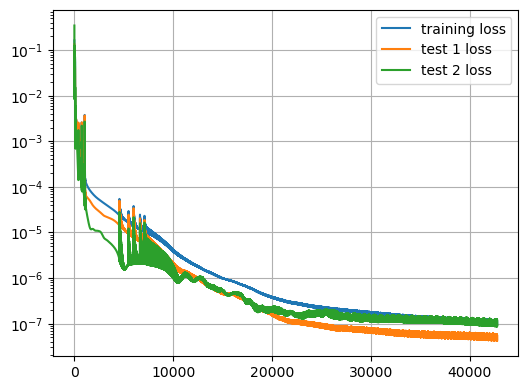

In [5]:
print_model_optimizer()
print_params()

[print(msg) for msg in msg_train] # [print(msg) for msg in msg_test

plt.figure(figsize=(6,4.5))
plt.semilogy(loss_v, label='training loss')
plt.semilogy(loss_t1_v, label='test 1 loss')
plt.semilogy(loss_t2_v, label='test 2 loss')
plt.legend()
plt.grid(True)
plt.savefig(fig_file, format="pdf", bbox_inches='tight')
plt.show()
